In [1]:
import sys

assert sys.version_info >= (3, 10)

In [2]:
import torch
from packaging.version import Version

assert Version(torch.__version__) >= Version("2.6.0")

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "Damped_Harmonic_Oscillator"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, fig_extension="png", tight_layout=True, resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [5]:
import deepxde as dde
from deepxde import utils
import numpy as np

dde.config.set_random_seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Setting the backend

In [6]:
dde.config.set_default_float("float64")
print(f"Backend: {dde.backend.backend_name}")

Set the default float type to float64
Backend: pytorch


We will now define the Physical parameters


In [7]:
m = 1.0 # Mass
c = 0.5 #Damping
k  = 4.0 # Stiffness

Now we will setup the Initial Conditions of the Damper

In [8]:
x0 = 1.0 # initial displacement
v0 = 0.0 # initial velocity

Now we will be deriving the parameters required to calculate our exact solution

In [9]:
omega_n = np.sqrt(k / m)
zeta = c / (2 * np.sqrt(m * k))
omega_d = omega_n * np.sqrt(1 - zeta**2)

We will define a function for our exact solution

In [10]:
def exact_solution(t):
    # In the formula we have an exponential term, cosine term and sine term
    exp_term = np.exp(-zeta * omega_n * t)
    cos_term = np.cos(omega_d * t)
    sin_term = (zeta * omega_n / omega_d) * np.sin(omega_d * t)
    return exp_term * (cos_term + sin_term)


We will create a function to calculate the exact velocity which is the derivative of displacement with respect to time

In [11]:
def exact_vx(t):
    exp_term  = np.exp(-zeta * omega_n * t)
    decay_rate = -zeta * omega_n

    x = exact_solution(t)
    dx_dt = decay_rate * x + exp_term * omega_d * (
        -np.sin(omega_d * t) + (zeta * omega_n / omega_d) * np.cos(omega_d *t)
    )
    print(dx_dt)
    return dx_dt

In [12]:
exact_vx(2)

0.8997813813378139


np.float64(0.8997813813378139)

We can also create a function with using autograd in torch but everything has to converted to torch tensors if we are working on "cuda" 

In [ ]:
def exact_vx1(t):
    if isinstance(t, torch.Tensor):
        t_tensor = t.clone().detach().requires_grad_(True)
    else:
        t_tensor = torch.tensor(t, requires_grad=True)
    x = exact_solution(t_tensor)
    x.backward(torch.ones_like(x))
    velocity = t_tensor.grad.cpu().detach()
    print(velocity)
    return velocity


Creating a geometry for our time domain


In [14]:
geom = dde.geometry.TimeDomain(0, 10)

Now let's write a function for the motion which is usually written using newton's second law which is an ODE equation

In [15]:
def ode(t, x):
    dx_dt = dde.grad.jacobian(x, t, i=0, j=0)
    d2w_d2t = dde.grad.hessian(x, t, i=0, j=0)

    residual = m * d2w_d2t + c * dx_dt + k * x
    return residual

specify the initial conditions

In [16]:
ic_displacement = dde.icbc.IC(geom, lambda t: x0, lambda _, on_initial: on_initial)

def velocity_ic(inputs, outputs, X):
    dx_dt = dde.grad.jacobian(outputs, inputs, i=0, j=0)
    return dx_dt - v0

def velocity_ic_location(t, on_initial):
    return on_initial and np.isclose(t[0], 0.0)

ic_velocity = dde.icbc.OperatorBC(
    geom, velocity_ic, velocity_ic_location
)


Generate some Training Data using numpy

In [17]:
observe_t = np.linspace(0, 10, 35).reshape(-1, 1)
observe_x = exact_solution(observe_t)
noise = 0.03 * np.random.randn(35, 1)
observe_x = observe_x + noise

observe = dde.icbc.PointSetBC(observe_t, observe_x, component=0)

Combining all the constraints

In [18]:
data = dde.data.TimePDE(
    geom, ode,
    [ic_displacement, ic_velocity, observe],
    num_domain=3000,
    num_boundary=200,
    num_test=500,
    anchors=observe_t
)

Build a Neural Network and create a model


In [19]:
net = dde.nn.FNN([1, 256,128, 64, 1], "tanh", "Glorot uniform")
model = dde.Model(data, net)

We can make Loss Weights as constants, instead we can make them adaptive
So we need to create a class for generating Self Adaptive Weights through a Callback function during training

In [21]:
class SoftmaxAdaptiveWeights(dde.callbacks.Callback):
    def __init__(self, model, every_n_epochs=100, alpha_0=1.0, gamma=0.999):
        super().__init__()
        self.model = model
        self.every_n_epochs = every_n_epochs
        self.alpha = alpha_0
        self.gamma = gamma
        self.epoch = 0

    def on_epoch_end(self):
        self.epoch += 1
        if self.epoch % self.every_n_epochs != 0:
            return
        if len(self.model.losshistory.loss_train) == 0:
            return
        current_losses = self.model.losshistory.loss_train[-1]
        exp_terms = np.exp(self.alpha * np.array(current_losses))
        new_weights = exp_terms / np.sum(exp_terms)
        self.alpha *= self.gamma
        self.model.loss_weights = new_weights.tolist()
        print(f"Epoch {self.epoch}: Adaptive weights updated to {new_weights.tolist()}, alpha decayed to {self.alpha:.4f}")

adaptive_callback = SoftmaxAdaptiveWeights(model, every_n_epochs=20)

Train the model

In [22]:
print("\n stage 1: Adam Optimizer")
model.compile(
    "adam", lr=0.001,
    loss_weights=[1.0] * 4,
    decay=("inverse time", 1000, 0.1)
)
losshistory, train_state = model.train(iterations=2000, display_every=200, callbacks=[adaptive_callback])
dde.optimizers.config.set_LBFGS_options(maxiter=200)
model.compile("L-BFGS", loss_weights=model.loss_weights)
losshistory, train_state = model.train(display_every=50, callbacks=[adaptive_callback])


 stage 1: Adam Optimizer
Compiling model...
'compile' took 0.000541 s

Training model...



/home/ziaur/ziazh/lib/python3.14/site-packages/torch/autograd/graph.py:882: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:370.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Step      Train loss                                  Test loss                                   Test metric
0         [6.94e-01, 1.00e+00, 6.40e-03, 1.66e-01]    [7.06e-01, 1.00e+00, 6.40e-03, 1.66e-01]    []  
Epoch 20: Adaptive weights updated to [0.2897734899420111, 0.3935773065786951, 0.14571868006938762, 0.17093052340990614], alpha decayed to 0.9990
Epoch 40: Adaptive weights updated to [0.28975321690925687, 0.39342929343829725, 0.14580868294966962, 0.1710088067027762], alpha decayed to 0.9980
Epoch 60: Adaptive weights updated to [0.289732922597872, 0.3932814255667918, 0.1458986296968113, 0.17108702213852486], alpha decayed to 0.9970
Epoch 80: Adaptive weights updated to [0.28971260711255525, 0.3931337028575807, 0.14598852028914877, 0.1711651697407154], alpha decayed to 0.9960
Epoch 100: Adaptive weights updated to [0.2896922705577615, 0.39298612520400905, 0.14607835470520056, 0.171243249533029], alpha decayed to 0.9950
Epoch 120: Adaptive weights updated to [0.2896719130377022

Evaluate the results

Create the test points 

In [23]:
test_points = 15
t_test = np.linspace(0, 10, test_points).reshape(-1, 1)
x_pred = model.predict(t_test)
x_exact = exact_solution(t_test)
noise = 0.03 * np.random.randn(15,1)
x_test = x_exact + noise

Calculate Errors

In [24]:
absolute_error = np.abs(x_test - x_pred)
relative_error = absolute_error / (np.abs(x_test) + 1e-10)
l2_error = np.linalg.norm(x_test - x_pred) / np.linalg.norm(x_test)
x_at_0 = model.predict(np.array([[0.0]]))[0, 0]
t_zero = np.array([[0.0]])
v_at_0 = model.predict(t_zero,
                       operator=lambda t, x: dde.grad.jacobian(x, t, i=0, j=0))[0, 0]

print("\n" + "="*60)
print("📊 PERFORMANCE METRICS")
print("="*60)
print(f"L2 Relative Error: {l2_error:.6f}")
print(f"Mean Absolute Error: {np.mean(absolute_error):.6f}")
print(f"Mean Absolute Relative Error: {np.mean(relative_error):.6f}")
print("\n📍 INITIAL CONDITION CHECK")
print("-"*60)
print(f"x(0) = {x_at_0:.6f} (Target: {x0})")
print(f"dx/dt(0) = {v_at_0:.6f} (Target: {v0})")
print("="*60)


📊 PERFORMANCE METRICS
L2 Relative Error: 0.100336
Mean Absolute Error: 0.028532
Mean Absolute Relative Error: 0.294024

📍 INITIAL CONDITION CHECK
------------------------------------------------------------
x(0) = 0.999972 (Target: 1.0)
dx/dt(0) = -0.000091 (Target: 0.0)


In [29]:
final_train_losses = model.losshistory.loss_train[-1]
print("FINAL TRAINING LOSSES".center(40))
print(f"ODE Loss            : {final_train_losses[0]:.6e}")
print(f"Displacement loss   : {final_train_losses[1]:.6e}")
print(f"Velocity Loss       : {final_train_losses[2]: .6e}")
print(f"Training Data Loss  : {final_train_losses[3]:.6e}")

         FINAL TRAINING LOSSES          
ODE Loss            : 7.841666e-06
Displacement loss   : 1.942331e-10
Velocity Loss       :  2.046849e-09
Training Data Loss  : 1.774422e-04


Visualization

1. Solution Comparision

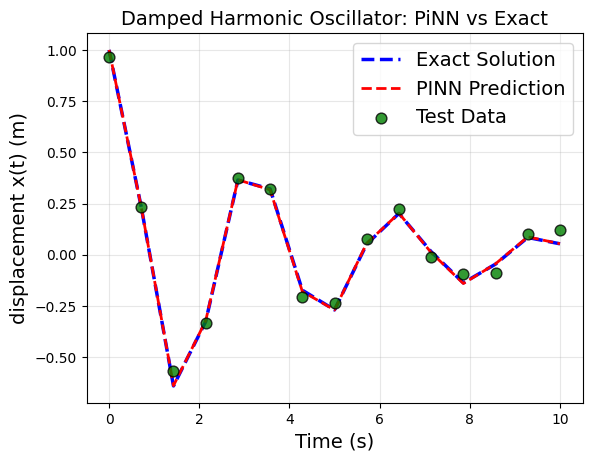

In [32]:
plt.plot(t_test, x_exact, 'b--', linewidth=2.5, label='Exact Solution')
plt.plot(t_test, x_pred, 'r--', linewidth=2, label='PINN Prediction')
plt.scatter(t_test, x_test, c='green', s=60,
            label="Test Data", zorder=5, alpha=0.8, edgecolors='black')
plt.xlabel('Time (s)')
plt.ylabel('displacement x(t) (m)')
plt.title('Damped Harmonic Oscillator: PiNN vs Exact')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


2. Global L2 Error Pie Chart

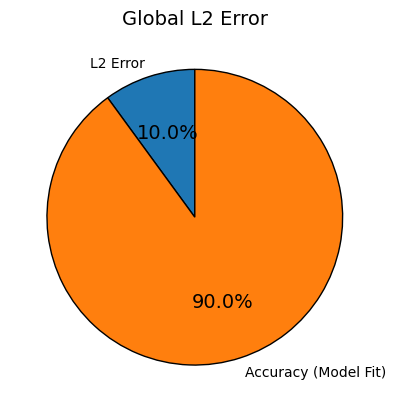

In [33]:
l2_error_pct = 100 * np.linalg.norm(x_test - x_pred) / np.linalg.norm(x_test)
sizes = [l2_error_pct, 100 - l2_error_pct]
labels = ['L2 Error', 'Accuracy (Model Fit)']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'})
plt.title("Global L2 Error")
plt.show()